# Import the Labraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Import the Dataset

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
california= fetch_california_housing()

In [4]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

# Information of the Dataset

In [5]:
## Checking the description of the dataset
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [6]:
california.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [7]:
california.target_names

['MedHouseVal']

# Preparing the Dataset

In [8]:
dataset = pd.DataFrame(california.data, columns=california.feature_names)

In [9]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [10]:
dataset['MedHouseVal'] = california.target

In [11]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [13]:
## Summarizing the stats of the dataset
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [14]:
## Checking the missing values
dataset.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [15]:
### Exploratory Data Analysis
## Correlation

dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [16]:
# sns.pairplot(dataset)

Text(0, 0.5, 'Median house value')

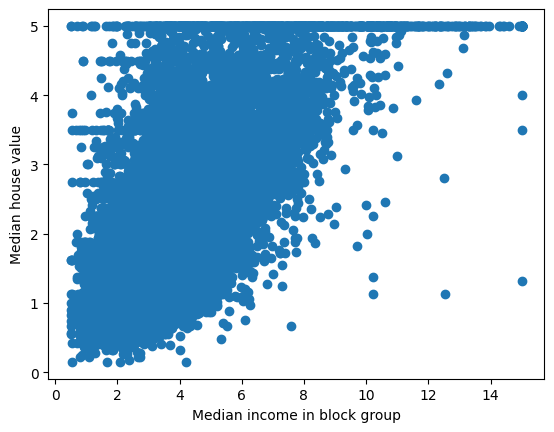

In [17]:
plt.scatter(dataset['MedInc'], dataset['MedHouseVal'])
plt.xlabel('Median income in block group')
plt.ylabel('Median house value')

<Axes: xlabel='MedInc', ylabel='MedHouseVal'>

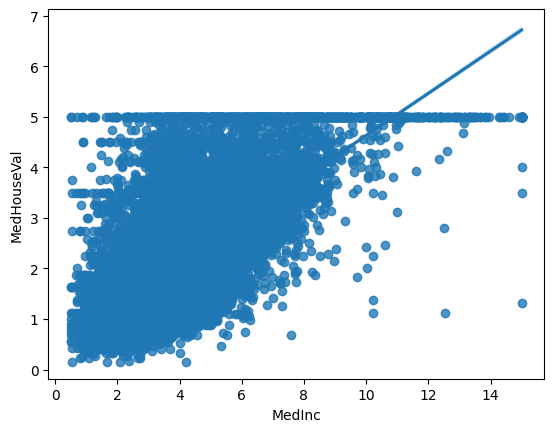

In [18]:
sns.regplot(x='MedInc', y='MedHouseVal', data=dataset)

<Axes: xlabel='HouseAge', ylabel='MedHouseVal'>

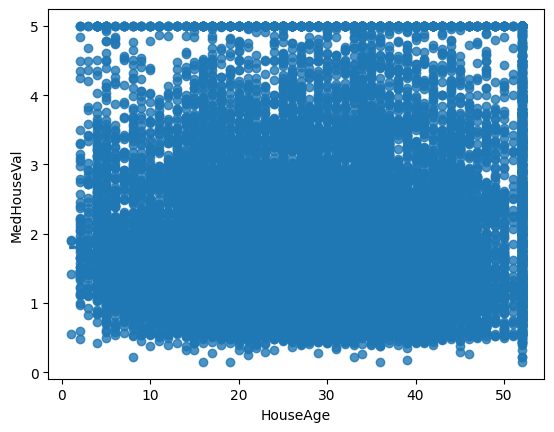

In [19]:
sns.regplot(x='HouseAge', y='MedHouseVal', data=dataset)

<Axes: xlabel='AveRooms', ylabel='MedHouseVal'>

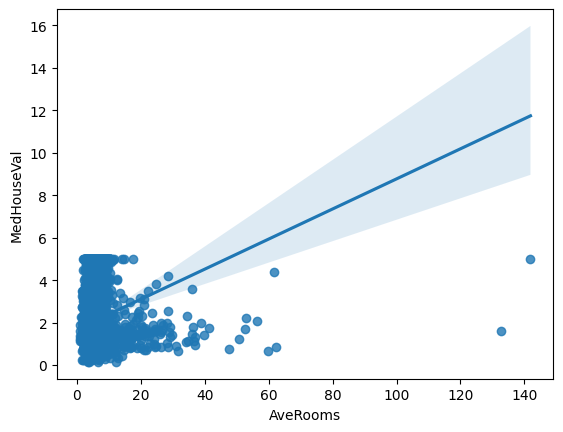

In [20]:
sns.regplot(x='AveRooms', y='MedHouseVal', data=dataset)

<Axes: xlabel='AveBedrms', ylabel='MedHouseVal'>

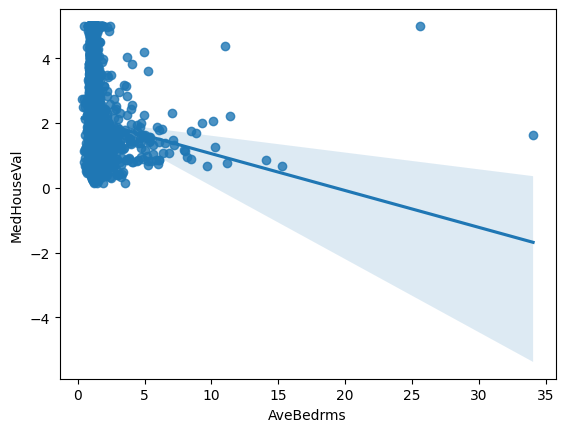

In [21]:
sns.regplot(x='AveBedrms', y='MedHouseVal', data=dataset)

<Axes: xlabel='Population', ylabel='MedHouseVal'>

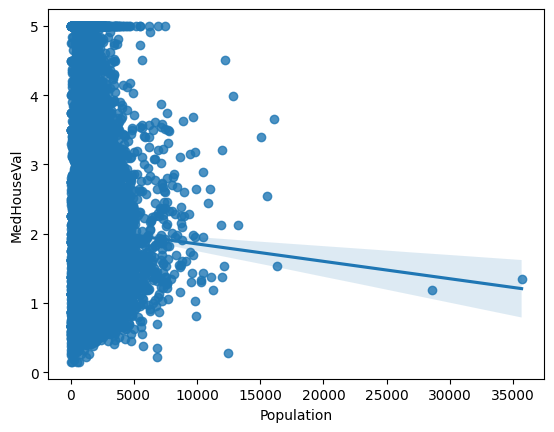

In [22]:
sns.regplot(x='Population', y='MedHouseVal', data=dataset)

<Axes: xlabel='AveOccup', ylabel='MedHouseVal'>

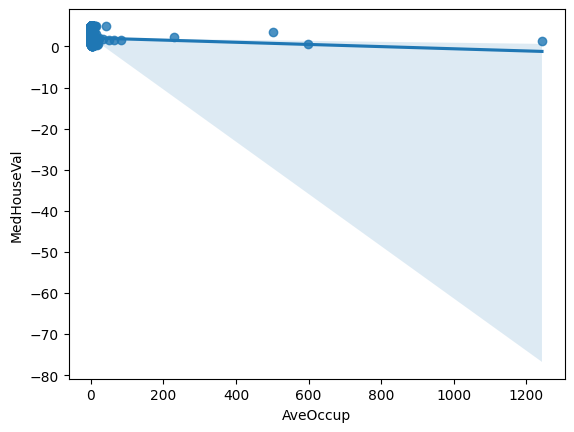

In [23]:
sns.regplot(x='AveOccup', y='MedHouseVal', data=dataset)

<Axes: xlabel='Latitude', ylabel='MedHouseVal'>

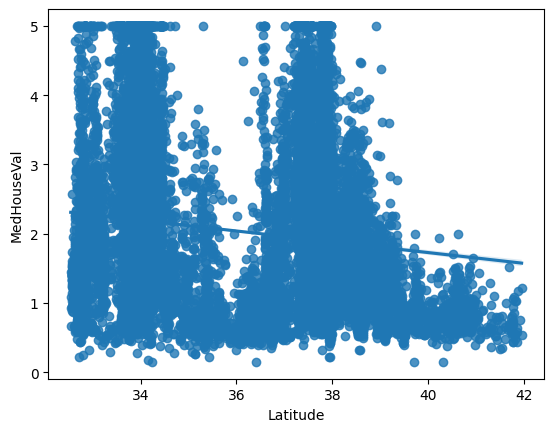

In [24]:
sns.regplot(x='Latitude', y='MedHouseVal', data=dataset)

<Axes: xlabel='Longitude', ylabel='MedHouseVal'>

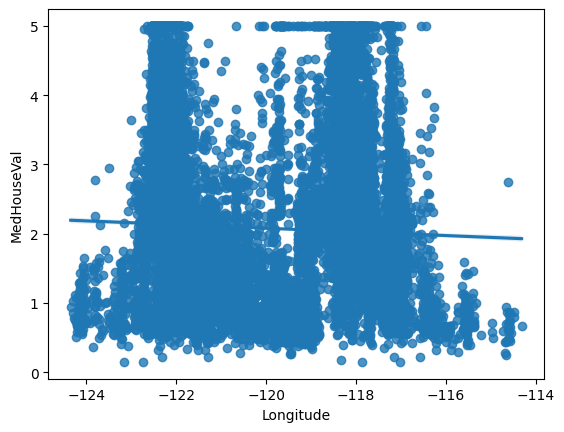

In [25]:
sns.regplot(x='Longitude', y='MedHouseVal', data=dataset)

In [26]:
X = dataset.iloc[:,:-1]
y = dataset.iloc[:, -1]

# Spliting the Training and Testing Data

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [28]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,4.1312,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02
14689,2.8631,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09
17323,4.2026,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14
10056,3.1094,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00
15750,3.3068,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [29]:
y_train

7061     1.93800
14689    1.69700
17323    2.59800
10056    1.36100
15750    5.00001
          ...   
11284    2.29200
11964    0.97800
5390     2.22100
860      2.83500
15795    3.25000
Name: MedHouseVal, Length: 14448, dtype: float64

# Normalization

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [31]:
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [32]:
X_train

array([[ 0.13350629,  0.50935748,  0.18106017, ..., -0.01082519,
        -0.80568191,  0.78093406],
       [-0.53221805, -0.67987313, -0.42262953, ..., -0.08931585,
        -1.33947268,  1.24526986],
       [ 0.1709897 , -0.36274497,  0.07312833, ..., -0.04480037,
        -0.49664515, -0.27755183],
       ...,
       [-0.49478713,  0.58863952, -0.59156984, ...,  0.01720102,
        -0.75885816,  0.60119118],
       [ 0.96717102, -1.07628333,  0.39014889, ...,  0.00482125,
         0.90338501, -1.18625198],
       [-0.68320166,  1.85715216, -0.82965604, ..., -0.0816717 ,
         0.99235014, -1.41592345]], shape=(14448, 8))

In [33]:
X_test

array([[-1.1526893 , -0.28346293, -0.50781822, ...,  0.06127763,
         0.19166399,  0.28664112],
       [-0.70640568,  0.11294728, -0.16252032, ..., -0.03551561,
        -0.23911452,  0.06196251],
       [-0.20830675,  1.85715216, -0.59546738, ..., -0.14215427,
         1.00639726, -1.42590916],
       ...,
       [-0.19155996, -0.99700129, -0.6830438 , ..., -0.06058827,
        -0.92742367,  0.8358555 ],
       [-0.11911302, -1.47269353,  0.02607207, ...,  0.03461374,
         1.01576201, -0.84673764],
       [-0.43304974, -0.91771925, -0.84872893, ..., -0.0407528 ,
        -0.70266966,  0.67109119]], shape=(6192, 8))

## Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
model.coef_

array([ 8.49221760e-01,  1.22119309e-01, -2.99558449e-01,  3.48409673e-01,
       -8.84488134e-04, -4.16980388e-02, -8.93855649e-01, -8.68616688e-01])

In [36]:
model.intercept_

np.float64(2.06923960894241)

In [37]:
y_pred = model.predict(X_test)

In [38]:
residuals = y_test - y_pred

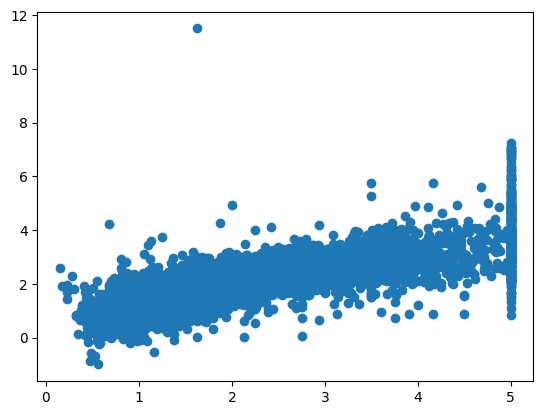

In [39]:
plt.scatter(y_test, y_pred)

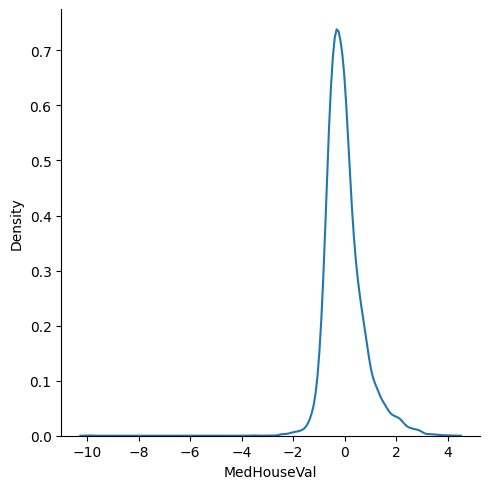

In [40]:
sns.displot(residuals, kind='kde')

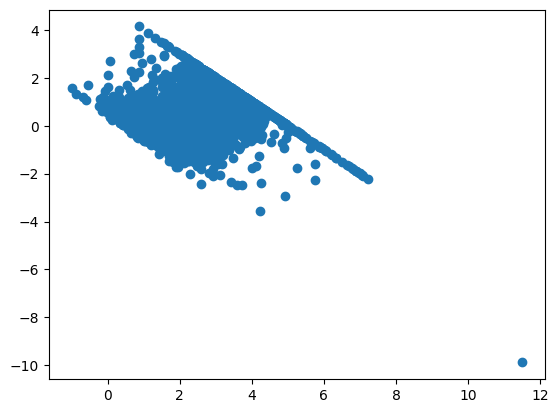

In [41]:
plt.scatter(y_pred, residuals)

In [42]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(np.sqrt(mean_squared_error(y_test, y_pred)))

0.5305677824766752
0.5272474538305951
0.7284008391515452


## Random Forest Regressor Model

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators = 300,
    max_depth=15,             # Stop trees from growing too deep
    min_samples_leaf=5,       # Require at least 5 houses per final prediction group
    min_samples_split=15,     # Require at least 15 houses to create a new branch
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [44]:
residuals_rf = y_test - y_pred_rf

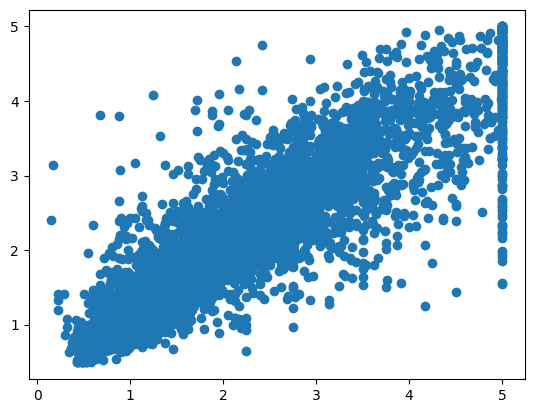

In [45]:
plt.scatter(y_test, y_pred_rf)

## Testing wheter the model is overfitting

In [46]:
y_pred_train = rf_model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Training RMSE: {train_rmse}")
print(f"Testing RMSE: {test_rmse}")

Training RMSE: 0.37764282106789926
Testing RMSE: 0.513573675675378


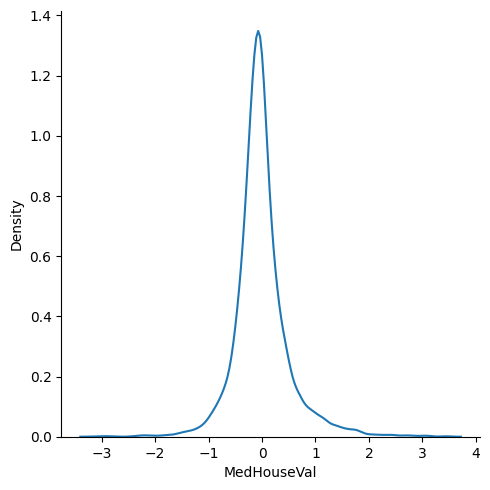

In [47]:
sns.displot(residuals_rf, kind='kde')

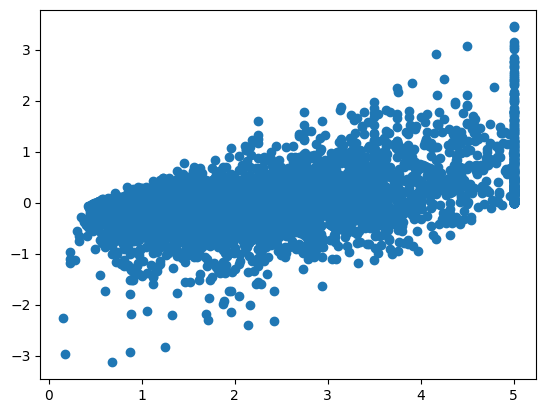

In [48]:
plt.scatter(y_test, residuals_rf)

In [49]:
print(mean_squared_error(y_test, y_pred_rf))
print(mean_absolute_error(y_test, y_pred_rf))
print(np.sqrt(mean_squared_error(y_test, y_pred_rf)))

0.2637579203467184
0.33797864921791965
0.513573675675378


## Hyperparameter Tuning (Optuna)

In [50]:
# import optuna
# import numpy as np
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error

# def objective(trial):

#     # 1. Define the parameters to fight overfitting
#     params = {
#         "n_estimators": trial.suggest_int("n_estimators", 100, 300),
#         "max_depth": trial.suggest_int("max_depth", 5, 10, 15),
#         "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 10, 15),
#         "min_samples_split": trial.suggest_int("min_samples_split", 10, 15, 20),

#     }

#     # 2. Build and train the Random Forest
#     model = RandomForestRegressor()
#     model.fit(X_train, y_train)

#     # 3. Predict and calculate the error
#     y_pred = model.predict(X_test)
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred))

#     # 4. Return the error
#     return rmse

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=30)

# print(" --- Optimazation Finished ---")
# print("Best Params:", study.best_params )
# print("Best RMSE:", study.best_value )

In [51]:
# from sklearn.ensemble import RandomForestRegressor
# import time

# best_params = study.best_params
# best_params.update({
#     "random_state": 42,
#     "n_jobs": -1
# })

# # Create model from best params
# rf = RandomForestRegressor(**best_params)

# # Training timer
# start_train = time.time()
# rf.fit(X_train, y_train)
# train_time = time.time() - start_train
# print(f"⏱ Training time: {train_time:.2f} seconds")

# y_pred_train = rf.predict(X_train)

# # Prediction timer
# start_pred = time.time()
# y_pred = rf.predict(X_test)
# pred_time = time.time() - start_pred
# print(f"⏱ Testing time: {pred_time:.2f} seconds")


# train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
# test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# print(f"Training RMSE: {train_rmse}")
# print(f"Testing RMSE: {test_rmse}")

In [52]:
# plt.scatter(y_test, y_pred)

In [53]:
# residuals = y_test - y_pred

In [54]:
# sns.displot(residuals, kind='kde')

In [55]:
# plt.scatter(y_test, residuals)

## R square and adjusted R square

In [56]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_rf)
print(score)

0.7990477252645425


In [57]:
# Display adjusted R-squared
adjusted_r2_score = 1 - (1-score)*(len(y_test)-1)/ (len(y_test)-X_test.shape[1]-1)
print(adjusted_r2_score)

0.7987877190866541


## New Data Prediction

In [58]:
california.data[0].reshape(1, -1)

array([[   8.3252    ,   41.        ,    6.98412698,    1.02380952,
         322.        ,    2.55555556,   37.88      , -122.23      ]])

In [59]:
scaler.transform(california.data[0].reshape(1, -1))

/Users/saiohmsaiepaine/Desktop/Projects/ML House Price Prediction/california_mediun_housing_prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 2.33526315,  0.98504972,  0.63012521, -0.16586931, -0.96995366,
        -0.04555657,  1.04385626, -1.32105914]])

In [60]:
rf_model.predict(scaler.transform(california.data[0].reshape(1, -1)))

/Users/saiohmsaiepaine/Desktop/Projects/ML House Price Prediction/california_mediun_housing_prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4.25838979])

In [61]:
california.target[0]

np.float64(4.526)

In [62]:
import pickle

In [63]:
pickle.dump(rf_model,open('randomforest.pkl', 'wb'))

In [64]:
pickle_model = pickle.load(open('randomforest.pkl', 'rb'))

In [65]:
pickle_model.predict(scaler.transform(california.data[0].reshape(1, -1)))

/Users/saiohmsaiepaine/Desktop/Projects/ML House Price Prediction/california_mediun_housing_prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4.25838979])